In [23]:
# ! pip install pandas matplotlib spacy gensim wordcloud pyLDAvis
# !python -m spacy download nl_core_news_sm
#!pip install sweetviz

In [24]:
# Basisbibliotheken voor data manipulatie en datumtijd
import pandas as pd
import numpy as np
from datetime import datetime
from collections import Counter
from sklearn.model_selection import train_test_split

# Visualisatiebibliotheken
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
import sweetviz as sv

# NLP en Machine Learning bibliotheken
import spacy
import gensim
from gensim import corpora
from gensim.models import Word2Vec

# Parameters en bestandsnamen instellen
afdelingsnaam = 'avondster'
filename_profielen = f'../zorgdata/gci_clienten_{afdelingsnaam}.csv'
filename_rapportages = f'../zorgdata/gci_rapportages_{afdelingsnaam}.csv'
num_topics = 5
seed = 6
no_below = 2   # Minimaal aantal rapportages waarin het woord moet voorkomen
no_above = 0.5 # Woorden die in meer van de documenten voorkomen worden gefilterd

# Laden van het Nederlands model voor SpaCy
# Het uitschakelen van onnodige componenten versnelt de verwerkingstijd
nlp = spacy.load('nl_core_news_sm', disable=['parser', 'tagger', 'ner'])

In [25]:
# Functie om de dag van de week en het weeknummer om te zetten naar een datum
def weekdag_naar_datum(weeknummer, dag_van_de_week, jaar=2024):
    # Controleer of weeknummer of dag_van_de_week NaN is
    if pd.isna(weeknummer) or pd.isna(dag_van_de_week):
        return pd.NA

    dag_index = ['maandag', 'dinsdag', 'woensdag', 'donderdag', 'vrijdag', 'zaterdag', 'zondag'].index(dag_van_de_week) + 1
    return datetime.fromisocalendar(jaar, weeknummer, dag_index).strftime('%Y-%m-%d')


In [26]:
def transformeer_rapportages(df_rapportages):
    disciplines = ['verzorgende', 'helpende', 'verpleegkundige']
    weekdagen = ['maandag', 'dinsdag', 'woensdag', 'donderdag', 'vrijdag', 'zaterdag', 'zondag']
    
    # Bereken de datum 
    df_rapportages['dag'] = pd.Categorical(df_rapportages['dag'], categories=weekdagen)
    df_rapportages['datum'] = df_rapportages.apply(lambda row: weekdag_naar_datum(row['weekno'], row['dag'], jaar=2024), axis=1)
    
    # Wijzig de onrustscore in een boolean: Wel/geen onrust
    df_rapportages['onrust'] = df_rapportages['onrustscore'] > 50

    # Zet de waarden van de 'niveau' kolom om naar lowercase voor consistentie
    df_rapportages['discipline'] = pd.Categorical(df_rapportages['niveau'].str.lower(), categories=disciplines)

    # Hernoem kolommen voor duidelijkheid en consistentie
    df_rapportages.rename(columns={'client_id': 'ct_id'}, inplace=True)

    # Selecteer relevante kolommen
    return df_rapportages[['ct_id', 'datum', 'discipline', 'rapportage', 'onrust', 'onrustscore']]


In [27]:
# Lees data in
df_rapportages = pd.read_csv(filename_rapportages, index_col=False)

In [28]:
df = transformeer_rapportages(df_rapportages).copy()

In [29]:
report = sv.analyze(df) 
report.show_html('report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [30]:
#Handjevol missings, die verwijder ik 
df = df.dropna()

In [31]:
# Text preprocessing
# Lowercasing, tokenisatie, lemmatisering, stopwoordverwijdering en woordselectie obv part-of-speech
def preprocess_text(text, nlp_model):
    doc = nlp_model(text)
    # Alle stappen worden samengevoegd in deze regel code
    cleaned_tokens = [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_stop and token.pos_ in ['VERB', 'NOUN', 'ADJ', 'ADV', 'INTJ']]
    # Terug omzetten naar een string
    return " ".join(cleaned_tokens)

# Pas de functie toe op de dataframe
df['rapportage_clean'] = df['rapportage'].apply(lambda x: preprocess_text(x, nlp))

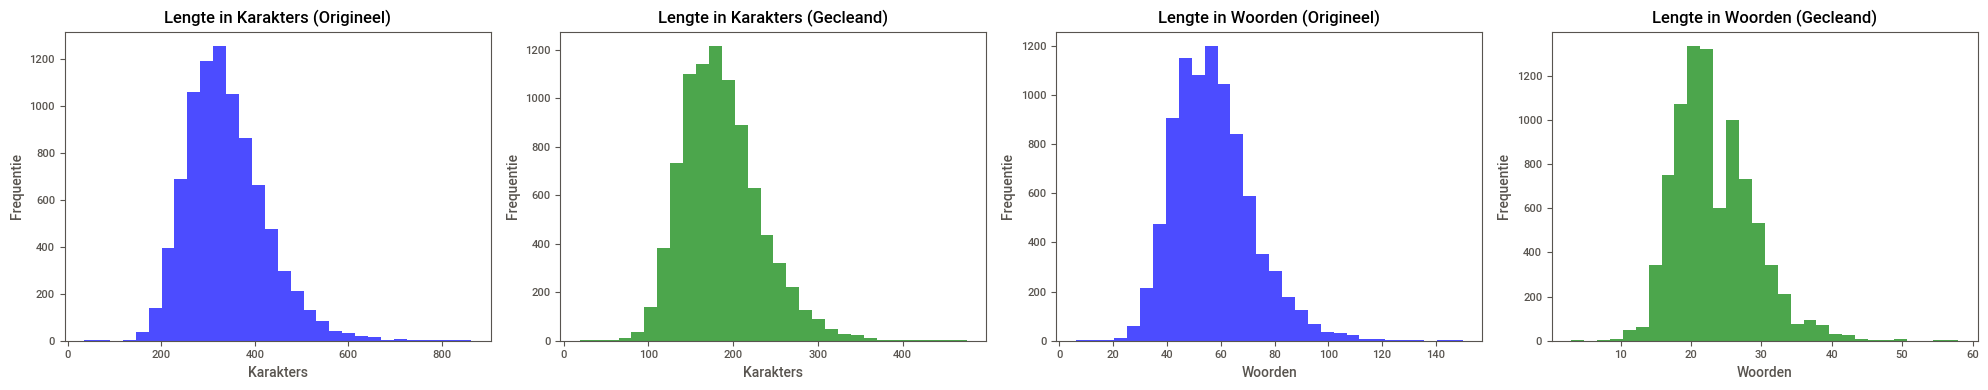

In [32]:
# Bereken lengtes in karakters en woorden
df['rapportage_len_chars'] = df['rapportage'].apply(len)
df['rapportage_clean_len_chars'] = df['rapportage_clean'].apply(len)
df['rapportage_len_words'] = df['rapportage'].apply(lambda x: len(x.split()))
df['rapportage_clean_len_words'] = df['rapportage_clean'].apply(lambda x: len(x.split()))

def plot_histogram(data, title, color, subplot_index, x_label, y_label='Frequentie', bins=30):
    plt.subplot(1, 4, subplot_index)
    plt.hist(data, bins=bins, color=color, alpha=0.7)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

# Instellen van de plotomgeving
plt.figure(figsize=(20, 4))  # grotere breedte om alle plots naast elkaar te passen

# Plotten van de histogrammen
plot_histogram(df['rapportage_len_chars'], 'Lengte in Karakters (Origineel)', 'blue', 1, 'Karakters')
plot_histogram(df['rapportage_clean_len_chars'], 'Lengte in Karakters (Gecleand)', 'green', 2, 'Karakters')
plot_histogram(df['rapportage_len_words'], 'Lengte in Woorden (Origineel)', 'blue', 3, 'Woorden')
plot_histogram(df['rapportage_clean_len_words'], 'Lengte in Woorden (Gecleand)', 'green', 4, 'Woorden')

plt.tight_layout()
plt.show()

In [33]:
# Splitten in train/test/validatie
# Dit doen we op clientniveau. Van de 24 clienten worden er 4 test, 4 validatie en 16 train.

unieke_clienten = df['ct_id'].unique()
train_ids, test_valid_ids = train_test_split(unieke_clienten, test_size=8, random_state=seed)
test_ids, valid_ids = train_test_split(test_valid_ids, test_size=4, random_state=seed)

train_df = df[df['ct_id'].isin(train_ids)].copy()
test_df = df[df['ct_id'].isin(test_ids)].copy()
valid_df = df[df['ct_id'].isin(valid_ids)].copy()

In [34]:
# Functie om wordclouds te genereren voor de topics die we gaan zoeken
def plot_wordclouds(lda_model, dictionary):
    plt.figure(figsize=(20, 10))  # Aanpassen van de breedte en hoogte van de plot
    for idx in range(lda_model.num_topics):
        plt.subplot(1, lda_model.num_topics, idx + 1)
        topic_words = dict(lda_model.show_topic(idx, 30))
        cloud = WordCloud(background_color='white').generate_from_frequencies(topic_words)
        plt.imshow(cloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('Topic ' + str(idx+1))

    plt.show()

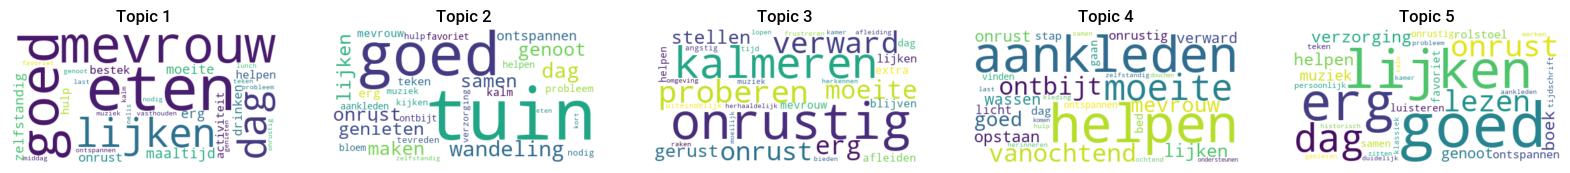

In [35]:
# Topic modelling. 
# Het model wordt gemaakt obv de trainingset, en vervolgens toegepast op alle data

# Tokeniseren van de gecleande rapportages met SpaCy
tokenized_docs_train = [[token.text for token in nlp(doc)] for doc in train_df['rapportage_clean']]
tokenized_docs_test = [[token.text for token in nlp(doc)] for doc in test_df['rapportage_clean']]
tokenized_docs_valid = [[token.text for token in nlp(doc)] for doc in valid_df['rapportage_clean']]

# Creëren van een dictionary
dictionary = corpora.Dictionary(tokenized_docs_train)
# Filter woorden die in meer dan 50% van de documenten voorkomen of in minder dan 2 documenten
dictionary.filter_extremes(no_below=no_below, no_above=no_above)

# Omzetten van documenten naar een bag-of-words representatie
corpus_train = [dictionary.doc2bow(doc) for doc in tokenized_docs_train]
corpus_test = [dictionary.doc2bow(doc) for doc in tokenized_docs_test]
corpus_valid = [dictionary.doc2bow(doc) for doc in tokenized_docs_valid]

# LDA model training
lda_model = gensim.models.LdaMulticore(corpus_train, num_topics=num_topics, id2word=dictionary, passes=10, workers=2, random_state=seed)

# Plot de topics
plot_wordclouds(lda_model, dictionary)

In [36]:
# Visualiseer met pyLDAvis 
lda_display = gensimvis.prepare(lda_model, corpus_train, dictionary, sort_topics=False)
pyLDAvis.display(lda_display)

In [37]:
# Functie om topic verdelingen te berekenen
def get_topic_distributions(lda_model, corpus):
    topic_distributions = []

    for doc_bow in corpus:
        doc_topics = lda_model.get_document_topics(doc_bow, minimum_probability=0)
        topic_distribution = {f'topic_{i}': 0 for i in range(num_topics)}
        for topic, prob in doc_topics:
            topic_distribution[f'topic_{topic}'] = prob
        topic_distributions.append(topic_distribution)
    
    return topic_distributions

# Bereken de topic verdelingen voor alle documenten
train_topic_dists = get_topic_distributions(lda_model, corpus_train)
test_topic_dists = get_topic_distributions(lda_model, corpus_test)
valid_topic_dists = get_topic_distributions(lda_model, corpus_valid)

# Voeg de topic verdelingen toe aan de DataFrames
for topic in range(num_topics):
    train_df[f'topic_{topic}'] = [dist[f'topic_{topic}'] for dist in train_topic_dists]
    test_df[f'topic_{topic}'] = [dist[f'topic_{topic}'] for dist in test_topic_dists]
    valid_df[f'topic_{topic}'] = [dist[f'topic_{topic}'] for dist in valid_topic_dists]

In [38]:
# Word embeddings
# Voorbereiden van de tekstdata
train_texts = [doc.split() for doc in train_df['rapportage_clean']]  # Zorg ervoor dat uw data is gesplitst in tokens
# Train het Word2Vec-model
word2vec_model = Word2Vec(sentences=train_texts, vector_size=50, window=5, min_count=1, workers=4)

In [39]:
def calculate_document_embedding(text, model):
    embeddings = [model.wv[word] for word in text.split() if word in model.wv]

    if not embeddings:
        return pd.Series(np.zeros(model.vector_size))

    mean_embedding = np.mean(embeddings, axis=0)
    return pd.Series(mean_embedding)

In [40]:
# Bereken de document embeddings en voeg deze toe aan de train DataFrame
embedding_columns = [f'embedding_{i}' for i in range(word2vec_model.vector_size)]
train_df[embedding_columns] = train_df['rapportage_clean'].apply(lambda x: calculate_document_embedding(x, word2vec_model))

# Doe hetzelfde voor test_df en valid_df
test_df[embedding_columns] = test_df['rapportage_clean'].apply(lambda x: calculate_document_embedding(x, word2vec_model))
valid_df[embedding_columns] = valid_df['rapportage_clean'].apply(lambda x: calculate_document_embedding(x, word2vec_model))


In [41]:
# Gebruik het getrainde model
word_embedding = word2vec_model.wv['onrust']  
print(word_embedding)

[ 0.20850645 -0.2526044  -0.3127509   0.555204   -0.79078937 -1.1686025
  1.4997454   0.751627   -0.85227364 -1.1331373   0.24426009 -1.5816523
  0.81849146  0.23719542 -0.649131    1.2907329   0.8772909   0.54544675
 -1.1740643   0.17255776  0.60442525  0.33451578  0.53812534  0.05614701
  1.1880627   0.8629536   0.85729563 -0.2771602  -1.3224512  -0.22438917
  0.20791498 -0.42153582 -1.0709819  -0.63190514 -0.31954744  0.09380197
  0.28997204  0.09181058  0.98657656 -0.5484817  -0.4605764   0.5458197
  0.77285165 -0.3235543   1.3370169   0.48580387  0.3616072   0.17681977
  0.9396608  -0.42722118]


In [42]:
# Vind de woorden die het meest vergelijkbaar zijn met 'onrust'
similar_words = word2vec_model.wv.most_similar('ontspannen', topn=10)

# Print de resultaten
for word, similarity in similar_words:
    print(f"Word: {word}, Similarity: {similarity}")


Word: genooten, Similarity: 0.9658251404762268
Word: stemming, Similarity: 0.9653263092041016
Word: schilderactiviteit, Similarity: 0.9605762362480164
Word: tevreden, Similarity: 0.9572019577026367
Word: krant, Similarity: 0.9526112079620361
Word: genoot, Similarity: 0.9505987167358398
Word: ïnteresseren, Similarity: 0.9485124349594116
Word: gezelschap, Similarity: 0.9454967975616455
Word: verlopen, Similarity: 0.944817304611206
Word: rest, Similarity: 0.9445996284484863


In [43]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5775 entries, 0 to 8698
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   ct_id                       5775 non-null   object  
 1   datum                       5775 non-null   object  
 2   discipline                  5775 non-null   category
 3   rapportage                  5775 non-null   object  
 4   onrust                      5775 non-null   bool    
 5   onrustscore                 5775 non-null   float64 
 6   rapportage_clean            5775 non-null   object  
 7   rapportage_len_chars        5775 non-null   int64   
 8   rapportage_clean_len_chars  5775 non-null   int64   
 9   rapportage_len_words        5775 non-null   int64   
 10  rapportage_clean_len_words  5775 non-null   int64   
 11  topic_0                     5775 non-null   float32 
 12  topic_1                     5775 non-null   float32 
 13  topic_2                

In [44]:
train_df.to_csv('../zorgdata/df_train.csv', index=False)
test_df.to_csv('../zorgdata/df_test.csv', index=False)
valid_df.to_csv('../zorgdata/df_valid.csv', index=False)

In [47]:
report = sv.analyze(train_df) 
report.show_html('report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
